# **Introduction**


Pada proyek ini dilakukan Exploratory Data Analysis (EDA) terhadap dataset Hotel Reservations untuk memahami pola pemesanan hotel serta faktor-faktor yang memengaruhi status reservasi pelanggan. Exploratory Data Analysis merupakan tahap awal dalam data mining dan data analysis yang bertujuan untuk memahami karakteristik data sebelum dilakukan proses analisis lebih lanjut atau pembuatan model machine learning.

Dataset yang digunakan berisi informasi mengenai reservasi hotel, seperti jumlah tamu, lama pemesanan sebelum check-in (lead time), jenis kamar yang dipesan, jenis meal plan, harga rata-rata kamar, hingga status pemesanan apakah dibatalkan atau tidak. Dengan melakukan analisis terhadap data tersebut, dapat diperoleh insight yang membantu dalam memahami perilaku pelanggan dan pola reservasi hotel.

Analisis ini dilakukan melalui beberapa tahapan, yaitu:
1. Memahami struktur dan karakteristik dataset
2. Memeriksa kualitas data seperti missing value dan data duplikat
3. Membersihkan data agar siap dianalisis
4. Melakukan analisis statistik dan visualisasi data
5. Menarik kesimpulan berdasarkan hasil analisis

Tujuan utama dari proyek ini adalah:
- Mengetahui karakteristik data reservasi hotel
- Mengidentifikasi pola pemesanan pelanggan
- Menemukan faktor yang memengaruhi pembatalan reservasi
- Menampilkan insight data melalui visualisasi yang mudah dipahami
- Membantu pengambilan keputusan berdasarkan data

Melalui proses EDA ini, diharapkan dapat diperoleh pemahaman yang lebih baik mengenai pola reservasi hotel serta hubungan antar variabel dalam dataset.

## **Sumber Dataset**

Dataset yang digunakan pada proyek ini berasal dari Kaggle dengan judul *Hotel Reservations Classification Dataset*.

link dataset : https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset

Dataset ini berisi informasi terkait reservasi hotel, termasuk detail pelanggan, tipe kamar, lead time, harga kamar, serta status pembatalan reservasi yang digunakan untuk proses analisis data dan visualisasi.

# **Data Understanding**



Dataset yang digunakan dalam proyek ini adalah dataset Hotel Reservations yang berisi data terkait reservasi pelanggan pada sebuah hotel. Setiap baris pada dataset merepresentasikan satu data pemesanan hotel oleh pelanggan.

Tahap Data Understanding dilakukan untuk memahami isi dataset, jenis data yang digunakan, jumlah data, serta informasi penting yang dapat digunakan pada proses analisis selanjutnya. Pemahaman terhadap data sangat penting agar proses pembersihan data dan analisis dapat dilakukan dengan tepat.

Dataset ini terdiri dari beberapa variabel numerik dan kategorikal yang menggambarkan informasi pelanggan dan detail reservasi hotel.

- Booking_ID  
  Merupakan ID unik untuk setiap reservasi pelanggan.

- no_of_adults  
  Menunjukkan jumlah orang dewasa dalam reservasi.

- no_of_children  
  Menunjukkan jumlah anak dalam reservasi.

- no_of_weekend_nights  
  Jumlah malam pada akhir pekan yang dipesan pelanggan.

- no_of_week_nights  
  Jumlah malam pada hari kerja yang dipesan pelanggan.

- type_of_meal_plan  
  Jenis paket makanan yang dipilih pelanggan selama menginap.

- required_car_parking_space  
  Menunjukkan apakah pelanggan membutuhkan tempat parkir atau tidak.

- room_type_reserved  
  Jenis kamar yang dipesan pelanggan.

- lead_time  
  Jarak waktu antara tanggal pemesanan dan tanggal check-in.

- arrival_year, arrival_month, arrival_date  
  Informasi waktu kedatangan pelanggan.

- market_segment_type  
  Jenis segmen pasar pelanggan, seperti online atau offline booking.

- repeated_guest  
  Menunjukkan apakah pelanggan pernah melakukan reservasi sebelumnya.

- no_of_previous_cancellations  
  Jumlah reservasi sebelumnya yang pernah dibatalkan pelanggan.

- no_of_previous_bookings_not_canceled  
  Jumlah reservasi sebelumnya yang tidak dibatalkan.

- avg_price_per_room  
  Rata-rata harga kamar yang dipesan pelanggan.

- no_of_special_requests  
  Jumlah permintaan khusus dari pelanggan.

- booking_status  
  Status reservasi pelanggan, apakah dibatalkan (Canceled) atau tidak dibatalkan (Not_Canceled).

Variabel yang menjadi fokus utama dalam analisis ini adalah booking_status karena variabel tersebut dapat digunakan untuk memahami faktor-faktor yang memengaruhi pembatalan reservasi hotel.

Pada tahap ini juga dilakukan pengecekan terhadap:
- Jumlah baris dan kolom dataset
- Tipe data setiap kolom
- Missing value
- Data duplikat
- Distribusi data
- Statistik deskriptif



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##**BLUE PRINT PROJECT**
Target variable = booking status.
Why Question/Factors:
1. Hubungan tipe perjalanan ke pembatalan, apakah family trip (yg bawa anak) lebih jarang cancel.
2. Hubungan Seasonal ke Cancelation
3. Hubungan fasilitas (meal/parking) ke cancelation.
4. Hubungan lead_time sama cancelation. Apakah ada pola nya? siapa tau diatas 10 hari kemungkinan cancel juga naik x%
5. Pesanan lebih banyak cancel di booking weekday atau weekend?
6. Tamu lebih banyak cancel di pesanan berapa hari? apakah 2 hari kebawah atau 3 hari ke atas? biasanya sih kalau yang booking buat waktu lama jarang cancel
7. Apakah pemesanan dengan tipe kamar tertentu memiliki pattern cancelation? (misal biasanya kamar luxury jarang cancel)
8. Hubungan market segment ke cancelation. Apakah booking dari channel tertentu lebih sering cancel?
9. Hubungan special request ke cancelation. Apakah semakin banyak request, kemungkinan cancel semakin kecil?
10. Hubungan harga kamar ke cancelation. Apakah booking dengan avg_price_per_room tinggi lebih sering cancel?
11. Apakah ada pola tertentu antara tamu yang repeat order dengan cancelation?

In [ ]:
df = pd.read_csv('/content/Hotel Reservations.csv')

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.shape

(36275, 19)

In [ ]:
df.shape
df.info() #lead_time = jarak hari dari booking

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
df.isna().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


In [ ]:
df_copy = df.copy()
df_copy.shape
df_copy.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df_copy['total_guests'] = df['no_of_adults'] + df['no_of_children']
anomaly = df_copy[df_copy['total_guests'] == 0]
anomaly.head() #normal

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests


# **Data Cleaning**

In [ ]:
for feature in df.columns:
  print(feature)
  print(df_copy[feature].unique())
  print('-'*20)

Booking_ID
['INN00001' 'INN00002' 'INN00003' ... 'INN36273' 'INN36274' 'INN36275']
--------------------
no_of_adults
[2 1 3 0 4]
--------------------
no_of_children
[ 0  2  1  3 10  9]
--------------------
no_of_weekend_nights
[1 2 0 4 3 6 5 7]
--------------------
no_of_week_nights
[ 2  3  1  4  5  0 10  6 11  7 15  9 13  8 14 12 17 16]
--------------------
type_of_meal_plan
['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']
--------------------
required_car_parking_space
[0 1]
--------------------
room_type_reserved
['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']
--------------------
lead_time
[224   5   1 211  48 346  34  83 121  44   0  35  30  95  47 256  99  12
 122   2  37 130  60  56   3 107  72  23 289 247 186  64  96  41  55 146
  32  57   7 124 169   6  51  13 100 139 117  39  86  19 192 179  26  74
 143 177  18 267 155  46 128  20  40 196 188  17 110  68  73  92 171 134
 320 118 189  16  24   8  10 182 116 123 105

In [ ]:
df_copy['no_of_adults'].value_counts() #ada anomali di 0, karena tidak mungkin booking hotel tanpa orang dewasa

,count
no_of_adults,
2,26108
1,7695
3,2317
0,139
4,16


In [ ]:
df_copy = df_copy[df_copy['no_of_adults']!= 0]

In [ ]:
df_copy['no_of_adults'].value_counts() #normal

,count
no_of_adults,
2,26108
1,7695
3,2317
4,16


In [ ]:
df_copy['no_of_children'].value_counts()

,count
no_of_children,
0,33577
1,1617
2,925
3,14
9,2
10,1


In [ ]:
df_copy[df_copy['no_of_children']>=9][['no_of_adults','no_of_children','room_type_reserved']] #outlier, bisa drop

,no_of_adults,no_of_children,room_type_reserved
6338,2,10,Room_Type 4
10041,1,9,Room_Type 1
10061,2,9,Room_Type 2


In [ ]:
df_copy = df_copy[df_copy['no_of_children']<9]

In [ ]:
df_copy['no_of_children'].value_counts()

,count
no_of_children,
0,33577
1,1617
2,925
3,14


In [ ]:
print(df_copy['lead_time'].describe())

count    36133.000000
mean        85.187612
std         85.952775
min          0.000000
25%         17.000000
50%         57.000000
75%        126.000000
max        443.000000
Name: lead_time, dtype: float64


In [ ]:
print(df_copy[df_copy['lead_time']>365].shape[0])

242


In [ ]:
df_copy = df_copy[df_copy['lead_time'] <= 365]
print(df_copy.shape)

(35891, 20)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


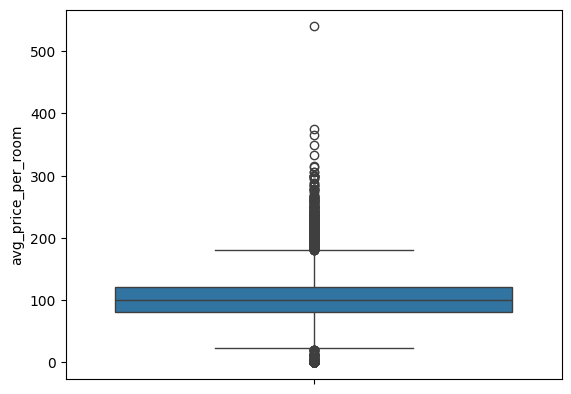

In [ ]:
sns.boxplot(df_copy['avg_price_per_room'])
plt.show() # ada anomali

In [ ]:
print(df_copy[df_copy['avg_price_per_room']==0]['market_segment_type'].unique())
#fix anomaly. ga mungkin ada harga online 0 rupiah

['Complementary' 'Online']


In [ ]:
print(df_copy[df_copy['market_segment_type']=='Complementary']['avg_price_per_room'].describe()) #ada anomali di nilai max. kita asumsikan complementary itu di bawah Q1 yaitu 25

count    386.000000
mean       3.159145
std       15.610227
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      170.000000
Name: avg_price_per_room, dtype: float64


In [ ]:
df_copy = df_copy[(df_copy['avg_price_per_room'].between(25,500))|((df_copy['market_segment_type']=='Complementary')&(df_copy['avg_price_per_room']<25))]
df_copy.shape

(35652, 20)

In [ ]:
df_copy[df_copy['avg_price_per_room'] < 25]['market_segment_type'].value_counts()

,count
market_segment_type,
Complementary,370


In [ ]:
print("Harga terendah di df_copy:", df_copy['avg_price_per_room'].min())

Harga terendah di df_copy: 0.0


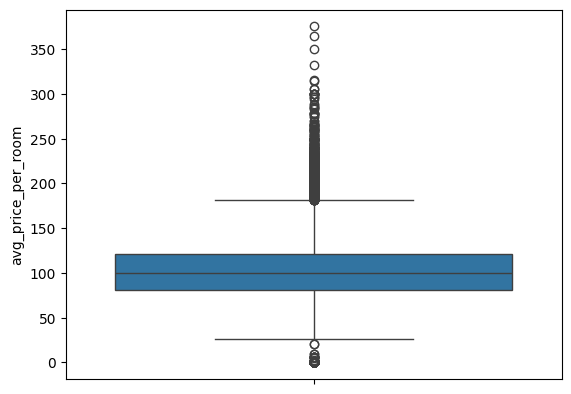

In [ ]:
sns.boxplot(df_copy['avg_price_per_room'])
plt.show() # ada anomali

In [ ]:
df_clean = df_copy.copy()

In [ ]:
df_clean.shape

(35652, 20)

In [ ]:
for feature in df_clean.columns:
  print(feature)
  print(df_clean[feature].unique())
  print('-'*20)

Booking_ID
['INN00001' 'INN00002' 'INN00003' ... 'INN36273' 'INN36274' 'INN36275']
--------------------
no_of_adults
[2 1 3 4]
--------------------
no_of_children
[0 2 1 3]
--------------------
no_of_weekend_nights
[1 2 0 4 3 6 5 7]
--------------------
no_of_week_nights
[ 2  3  1  4  5  0 10  6 11  7 15  9 13  8 14 12 17 16]
--------------------
type_of_meal_plan
['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']
--------------------
required_car_parking_space
[0 1]
--------------------
room_type_reserved
['Room_Type 1' 'Room_Type 4' 'Room_Type 6' 'Room_Type 5' 'Room_Type 2'
 'Room_Type 7' 'Room_Type 3']
--------------------
lead_time
[224   5   1 211  48 346  34  83 121  44   0  35  30  95  47 256  99  12
 122   2  37 130  60  56   3 107  72  23 289 247 186  64  96  41  55 146
  32  57   7 124 169   6  51  13 100 139 117  39  86  19 192 179  26  74
 143 177  18 267 155  46 128  20  40 196 188  17 110  68  73  92 171 134
 320 118 189  16  24   8  10 182 116 123 105 317 286 148

#**Business question**


## **1. Hubungan tipe perjalanan ke pembatalan, apakah family trip (yg bawa anak) lebih jarang cancel**

In [ ]:
#business question no 1
#syarat familiy trip itu minimal one adult and at least 1 child
#Hipotesis:
family_condition= (df_clean['no_of_adults'] >=1) &(df_clean['no_of_children']>=1)
df_clean['family_trip']= family_condition
ct = df_clean.groupby('family_trip')['booking_status'].value_counts(normalize=True).unstack()*100
print(ct)
#kalau di lihat hasilnya baik yang family trip ataupun yang  non-family ga terlalu besar pengaruhnya ke cancelation

booking_status   Canceled  Not_Canceled
family_trip                            
False           32.126027     67.873973
True            37.598116     62.401884


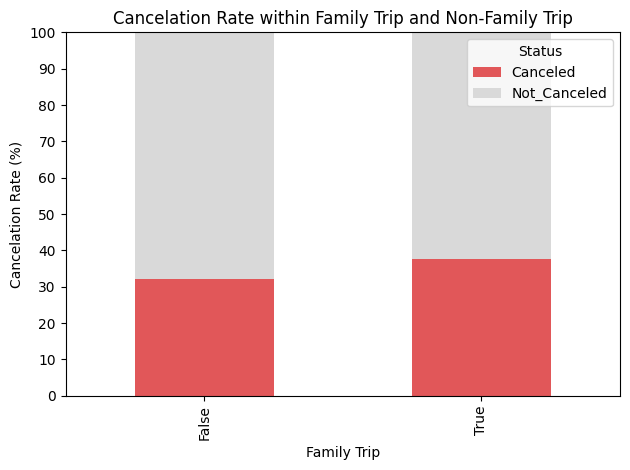

In [ ]:
ct.plot(kind = 'bar', stacked= True, color=['#E15759', '#D9D9D9'])

plt.title('Cancelation Rate within Family Trip and Non-Family Trip')
plt.xlabel('Family Trip')
plt.ylabel('Cancelation Rate (%)')
plt.ylim(0, 100)
plt.yticks(range(0,101,10))
plt.tight_layout()
plt.legend(title='Status')
plt.grid(False)
plt.savefig('cancelation_family.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()

### **Kesimpulan nomor 1**
Family trip memiliki perluang sebesar 32%, dan non-family trip memiliki peluang 37.59%. Keduanya menunjukkan tingkat pembatalan yang relatif tinggi. Namun selisih diantara kedua tipe perjalanan ini tidak terlalu besar,segingga dapat disimpulkan bahwa tipe perjalanan tidak memiliki pengaruh signifikan terhadap peluang cancelation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

## **2. Apakah ada pengaruh seasonal ke cancelation?**

<function matplotlib.pyplot.show(close=None, block=None)>

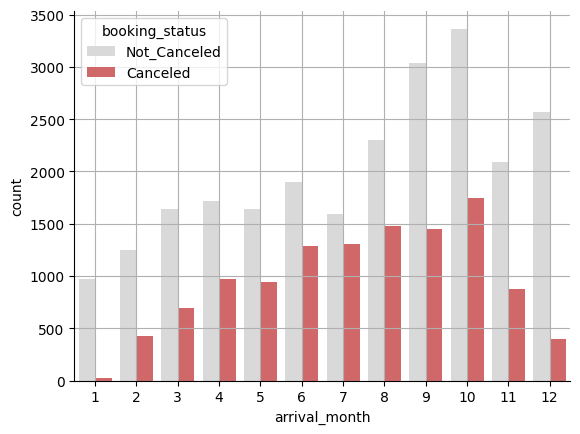

In [ ]:
#Question 2:  Hubungan Seasonal ke Cancelation
# hipotesis : Seosonal biasanya memiliki pengaruh yang cukup tinggi terhadap cancelation. Misalnya saat high season.
# Customer cenderung melakukan panic booking dengan booking dibebrapa hotel sekaligus. Sehingga peluang cancelation juga semakin tinggi

sns.countplot(data=df_clean, x='arrival_month', hue='booking_status', palette= ['#D9D9D9', '#E15759'])
sns.despine()
sns.set_theme(font="serif")
plt.grid('False')
plt.savefig('countplot_seasonal.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show


In [ ]:
monthly_ratio = df_clean.groupby('arrival_month')['booking_status'].value_counts(normalize=True).unstack()*100
monthly_cancel_rate= monthly_ratio.sort_values(by='Canceled', ascending = False)
print(monthly_cancel_rate)

booking_status   Canceled  Not_Canceled
arrival_month                          
7               45.077720     54.922280
6               40.470958     59.529042
8               39.120064     60.879936
5               36.609907     63.390093
4               36.093576     63.906424
10              34.193548     65.806452
9               32.291899     67.708101
3               29.623288     70.376712
11              29.425676     70.574324
2               25.432836     74.567164
12              13.378378     86.621622
1                2.412060     97.587940


In [ ]:
cancel_rate = monthly_cancel_rate['Canceled'].sort_index()

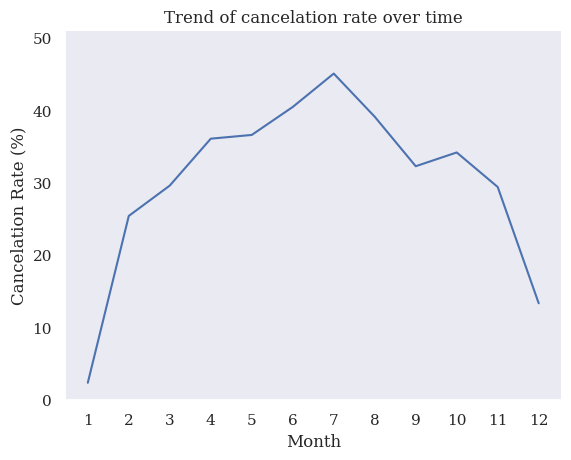

In [ ]:
cancel_rate.plot(kind='line')
plt.title('Trend of cancelation rate over time')
plt.xlabel('Month')
plt.xticks(range(1,13,1))
plt.ylabel('Cancelation Rate (%)')
plt.ylim(0,51)
plt.yticks(range(0,51,10))
plt.grid(True, linestyle= '--', alpha=0.5)
sns.despine()
plt.grid(False)

plt.savefig('cancelation_seasonal.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()




In [ ]:
df_total_canceled = df_clean[df_clean['booking_status']=='Canceled']
cancelation_rate = df_total_canceled['arrival_month'].value_counts(normalize=True)*100
print(cancelation_rate.sort_values(ascending=False))

arrival_month
10    15.086690
8     12.731821
9     12.481670
7     11.256793
6     11.118779
4      8.384370
5      8.160097
11     7.513154
3      5.969119
2      3.674631
12     3.415854
1      0.207021
Name: proportion, dtype: float64


### **Kesimpulan nomor 2**
Hasil menunjukkan bahwa bulan Juli memiliki rasio cancelation tertinggi dibandingkan bulan lainnya, yaitu sebesar 45.07% dari total pemesanan. Meskipun jumlah pembatalan tertinggi secara absolut terjadi pada bulan Oktober, selisih antara jumlah pemesanan yang dibatalkan dan tidak dibatalkan juga cukup besar. Hal ini menunjukkan bahwa total pemesanan  secara keseluruhan tetap tinggi, sehingga risiko terhadap pendapatan hotel pada bulan Oktober relatif rendah dibandingkan bulan Juli.

## **3. Hubungan fasilitas (meal/parking) ke cancelation**

In [ ]:
#Question 3: Hubungan fasilitas (meal/parking) ke cancelation
#Hipotesis: pelanggan yang memesan layanan tambahan seperti tempat parkir dan meal service cenderung jarang melakukan pembatalan
df_clean['has_meal'] = df_clean['type_of_meal_plan'] != 'Not Selected'
df_clean['has_parking'] = df_clean['required_car_parking_space'] >0

mp = df_clean['has_meal']|df_clean['has_parking']

In [ ]:
df_clean['meal_park'] = mp
meal_park = df_clean.groupby('meal_park')['booking_status'].value_counts(normalize = True).unstack()*100


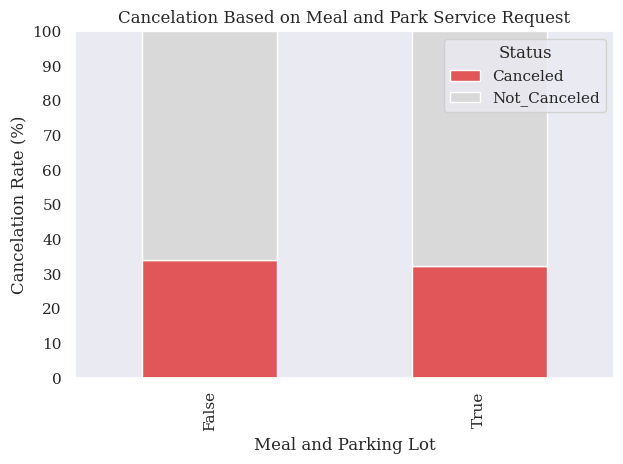

In [ ]:

meal_park.plot(kind = 'bar', stacked= True, color=['#E15759', '#D9D9D9'])

plt.title('Cancelation Based on Meal and Park Service Request')
plt.xlabel('Meal and Parking Lot')
plt.ylabel('Cancelation Rate (%)')
plt.ylim(0, 100)
plt.yticks(range(0,101,10))
plt.tight_layout()
plt.legend(title='Status')
plt.grid(False)
plt.savefig('meal_park.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()

### **Kesimpulan nomor 3**
Pelanggan tanpa extra services menunjukkan peluang pembatalan sebesar 33.9%, sementara pelanggan dengan pemesaraan  extra services memiliki peluang sebesar 32.2%. Meskipun kedua kategori memiliki peluang pembatalan yang cukup tinggi, selisih dari keduanya hanya 1.7%. Sehingga dapat disimpulkan bahwa penggunaan extra services umum nya tidak memiliki pengaruh yang signifikan terhadap pembatalan reservasi hotel

##**4. Hubungan lead_time sama cancelation. Apakah ada pola nya? siapa tau diatas 10 hari kemungkinan cancel juga naik x%**


In [ ]:
#business question no 4
#hipotesis = makin lama jarak booking ke hari-h makin besar kemungkinan di cancel.
def kategori_lead_time(x):
  if x <= 7: return 'last minute'
  if x <= 30: return  'medium term'
  return 'long term'
df_clean['lead_time_category'] = df_clean['lead_time'].apply(kategori_lead_time)
lead_time_rate= df_clean.groupby('lead_time_category')['booking_status'].value_counts(normalize=True).unstack()*100
print(lead_time_rate)

booking_status       Canceled  Not_Canceled
lead_time_category                         
last minute          9.039548     90.960452
long term           41.994706     58.005294
medium term         18.998932     81.001068


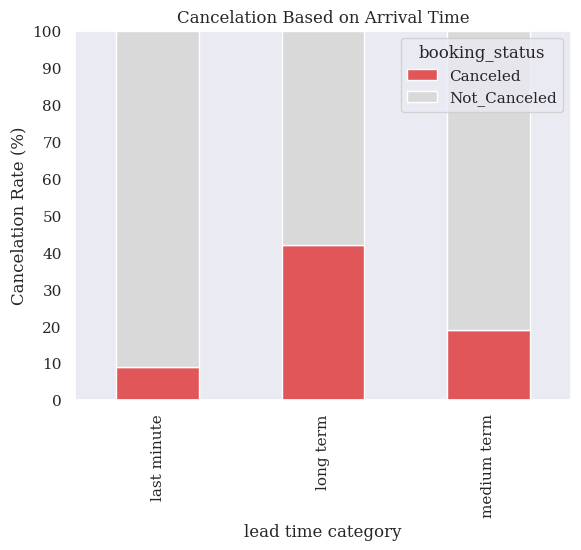

In [ ]:

lead_time_rate.plot(kind = 'bar', stacked= True, color=['#E15759', '#D9D9D9'])

plt.title('Cancelation Based on Arrival Time')
plt.xlabel('lead time category')
plt.ylabel('Cancelation Rate (%)')
plt.ylim(0, 100)
plt.yticks(range(0,101,10))
plt.grid(False)
plt.savefig('lead_time_cancellation.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()

### **Kesimpulan nomor 4**
Semakin panjang jarak antara booking time dan check-in, semakin besar peluang pembatalan yang akan terjadi. Peluang paling besar terjadin pada lead time diatas 30 hari dengan tingkat cancelation sebesar 41.9%. Namum, umumanya hal ini tidak selalu merugikan hotel, karena masih terdapay cukup waktu untuk menjual kamar kembali

**Dapat disimpulkan bahwa lead time merupakan faktor penting yang dapat digunakan untuk memprediksi risiko pembatalan dan memberikan inside baru dalam aturan refund dan deposit**

##**5. Pesanan lebih banyak cancel di booking weekday atau weekend?**

In [ ]:
df_clean['no_of_weekend_nights'].value_counts()

,count
no_of_weekend_nights,
0,16524
1,9866
2,8927
3,152
4,128
5,34
6,20
7,1


In [ ]:
(df_clean['no_of_weekend_nights']+df_clean['no_of_week_nights']==0).sum()

np.int64(13)

In [ ]:
df_clean = df_clean[(df_clean['no_of_week_nights']+df_clean['no_of_weekend_nights']>0)]

In [ ]:
df_clean['weekend_ratio']=df_clean['no_of_weekend_nights']/(df_clean['no_of_week_nights']+df_clean['no_of_weekend_nights'])

In [ ]:
df_clean['weekend_group'] = pd.cut(df_clean['weekend_ratio'], bins = [0, 0.3, 0.7, 1], labels = ['weekday', 'mixed', 'weekend'])

In [ ]:
stay_composition = df_clean.groupby('weekend_group')['booking_status'].value_counts(normalize=True).unstack()*100

/tmp/ipykernel_11736/1750951588.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stay_composition = df_clean.groupby('weekend_group')['booking_status'].value_counts(normalize=True).unstack()*100


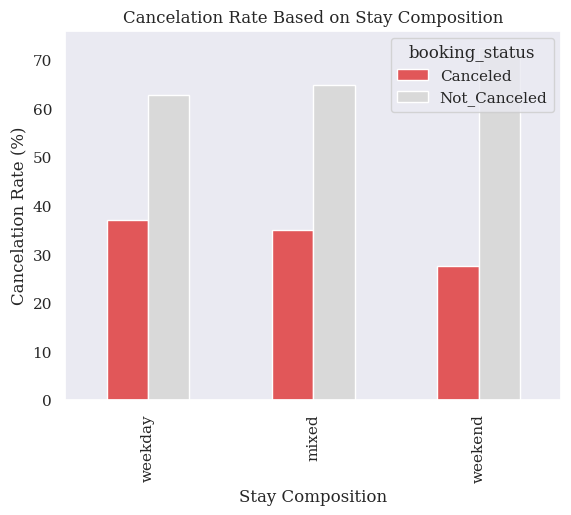

In [ ]:
stay_composition.plot(kind = 'bar', color =['#E15759', '#D9D9D9'])
plt.title('Cancelation Rate Based on Stay Composition')
plt.xlabel('Stay Composition')
plt.ylabel('Cancelation Rate (%)')
plt.grid(False)
plt.savefig('cancelation_stay_composition.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()

Disini kita menghitung komposisi durasi menginap, bukan hari booking. Total lama menginap dibagi menjadi malam weekday and malam weekend. Untuk memahami proporsi datanya kita menggunakan weekend ratio, yaitu jumlah malam  weekend/ total malam menginap. Kalau ratio rendah (0-0.3), mostly tamu menginap di weekday. Jika ada di rentang 0.3-0.7 maka komposisinya relatif seimbang. Sedangkan jika rasio tinggi 0.7-0.1 maka mayoritas tamu menginap di weekend

###**Kesimpulan no 5**
Hasil analisis menunjukkan bahwa pelanggan dengan komposisi menginap yang yang di dominasi weekday memiliki peluang cancelation sebesar 37%, sedangkan pelanggan dengan komposisi campuran memiliki selisih peluang 2%, hasil ini tidak menunjukkan perbedaan yang signifikan.
Namun yang perlu diperhatikan disini adalah, pelanggan yang cenderung menginap pada akhir perkan memiliki tingkat pembatalan yang lebih rendah, hanya 27%, terdapat selisih 8-10% dibandingkan dengan weekday and mixed.
Hal ini mengindikasikan bahwa komposisi waktu menginap dapat mempengaruhi kemungkinan cancelation, dimana pelanggan

## **6. Tamu lebih banyak cancel di pesanan berapa hari? apakah 2 hari kebawah atau 3 hari ke atas? biasanya kalau yang booking buat waktu lama jarang cancel**


Kolom total_stay_nights dibuat dari jumlah malam weekday dan weekend. Jadi kita bisa tahu total lama tamu menginap dalam satu booking.

In [ ]:
#business question no 6
#hipotesis = tamu yang booking untuk waktu lama cenderung lebih jarang cancel
#karena biasanya rencana menginap lama lebih matang

df_clean['total_stay_nights'] = df_clean['no_of_week_nights'] + df_clean['no_of_weekend_nights']

In [ ]:
df_clean['total_stay_nights'].value_counts()

,count
total_stay_nights,
3,9900
2,8251
1,6501
4,5849
5,2566
6,1024
7,968
8,179
9,111


bandingin persentase Canceled dan Not_Canceled berdasarkan kategori lama menginap, nanti lihat kolom Canceled. kalau persentase Canceled di 3+ nights lebih kecil, berarti hipotesis “booking lama lebih jarang cancel” bisa didukung

In [ ]:
def kategori_lama_menginap(x):
  if x <= 3:
    return 'short'
  if 7>=x>3:
    return 'medium'
  else:
    return 'long'

df_clean['stay_category'] = df_clean['total_stay_nights'].apply(kategori_lama_menginap)

stay_ratio = df_clean.groupby('stay_category')['booking_status'].value_counts(normalize=True).unstack()*100
print(stay_ratio)

booking_status   Canceled  Not_Canceled
stay_category                          
long            54.827586     45.172414
medium          34.399923     65.600077
short           31.214506     68.785494


In [ ]:
sc = df_clean['stay_category'].value_counts(ascending=True)
print (sc)

stay_category
long        580
medium    10407
short     24652
Name: count, dtype: int64


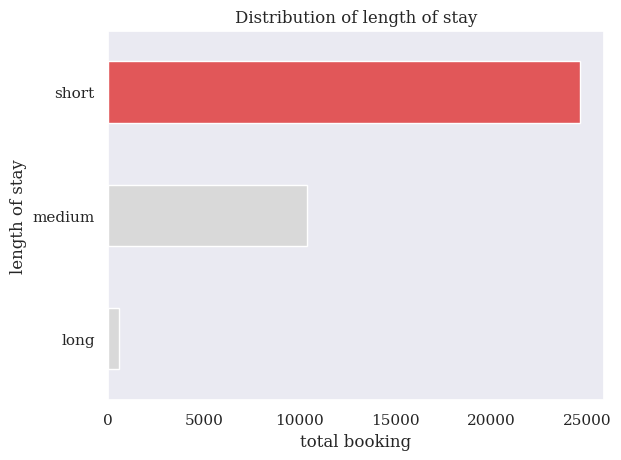

In [ ]:
sc.plot(kind = 'barh', color = ['#D9D9D9','#D9D9D9','#E15759'])
plt.ylabel('length of stay')
plt.xlabel('total booking')
plt.grid(False)
plt.title('Distribution of length of stay')
plt.savefig('distribution_length_of_stay.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()

Berdasarkan hasil grouping stay_category terhadap booking_status,
- booking dengan kategori 1-2 nights memiliki cancellation rate sebesar 28.45%,
- booking dengan kategori 3+ nights memiliki cancellation rate sebesar 35.39%.

ini menunjukkan bahwa tamu yang menginap lebih lama justru memiliki tingkat pembatalan yang lebih tinggi dibandingkan tamu yang menginap singkat. Dengan demikian, hipotesis awal bahwa **booking dengan durasi lama lebih jarang cancel tidak terbukti pada dataset ini.**

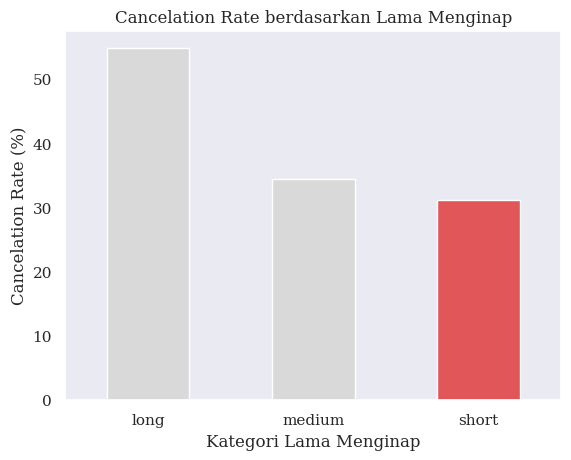

In [ ]:
stay_ratio['Canceled'].plot(kind='bar', color = ['#D9D9D9','#D9D9D9', '#E15759'])

plt.title('Cancelation Rate berdasarkan Lama Menginap')
plt.xlabel('Kategori Lama Menginap')
plt.ylabel('Cancelation Rate (%)')
plt.xticks(rotation=0)
plt.grid(False)
plt.savefig('cancelation_length_of_stay.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()

Kategori 3+ nights memiliki cancellation rate yang lebih tinggi dibandingkan kategori 1-2 nights --> artinya, semakin lama durasi menginap, kemungkinan pembatalan tidak semakin kecil, melainkan cenderung lebih besar pada data ini.

### **Kesimpulan nomor 6**
Dari hasil analisis,
- tamu dengan durasi menginap 3 malam atau lebih memiliki cancellation rate sebesar 35.39%, lebih tinggi dibandingkan tamu dengan durasi 1-2 malam yang memiliki cancellation rate sebesar 28.45%.

Oleh karena itu, dapat disimpulkan bahwa pada dataset ini, **booking dengan durasi menginap lebih lama cenderung lebih sering cancel dibandingkan booking dengan durasi singkat.**

## **7. Apakah pemesanan dengan tipe kamar tertentu memiliki pattern cancelation? (misal biasanya kamar luxury jarang cancel)**

In [ ]:
#business question no 7
#hipotesis = tipe kamar tertentu memiliki tingkat cancelation yang berbeda
#misalnya kamar dengan tipe lebih tinggi/luxury mungkin lebih jarang cancel

print(df_clean['room_type_reserved'].value_counts())

room_type_reserved
Room_Type 1    27666
Room_Type 4     6039
Room_Type 6      962
Room_Type 2      548
Room_Type 5      261
Room_Type 7      156
Room_Type 3        7
Name: count, dtype: int64


ini buat nunjukin jumlah booking pada setiap tipe kamar.
- Room_Type 1, jumlah booking paling banyak, yaitu 27.675 booking, jadi tipe kamar ini merupakan tipe kamar yang paling sering dipesan.
- Room_Type 4 jumlah booking nya 6.042 booking,
- sedangkan tipe kamar lain punya jumlah booking yang jauh lebih sedikit. Room_Type 3 hanya memiliki 7 booking, jadi hasil analisis pada tipe kamar ini perlu diperhatikan dengan hati-hati karena jumlah datanya sangat kecil.

In [ ]:
room_ratio = df_clean.groupby('room_type_reserved')['booking_status'].value_counts(normalize=True).unstack() * 100

print(room_ratio)

booking_status       Canceled  Not_Canceled
room_type_reserved                         
Room_Type 1         31.901974     68.098026
Room_Type 2         33.394161     66.605839
Room_Type 3         28.571429     71.428571
Room_Type 4         34.260639     65.739361
Room_Type 5         27.203065     72.796935
Room_Type 6         42.203742     57.796258
Room_Type 7         23.076923     76.923077


Tabel ini nunjukin persentase booking yang Canceled dan Not_Canceled pada setiap tipe kamar. Berdasarkan hasil tersebut,
- setiap tipe kamar memiliki tingkat cancellation yang berbeda-beda.
- Room_Type 6 memiliki cancellation rate paling tinggi, yaitu 42.20%,
- Room_Type 7 memiliki cancellation rate paling rendah, yaitu 23.08%.

Hal ini menunjukkan bahwa tipe kamar tertentu memang memiliki pola cancellation yang berbeda dibandingkan tipe kamar lainnya.

In [ ]:
room_cancel_rate = room_ratio['Canceled'].sort_values(ascending=False)

print(room_cancel_rate)

room_type_reserved
Room_Type 6    42.203742
Room_Type 4    34.260639
Room_Type 2    33.394161
Room_Type 1    31.901974
Room_Type 3    28.571429
Room_Type 5    27.203065
Room_Type 7    23.076923
Name: Canceled, dtype: float64


ini mengurutkan tipe kamar berdasarkan cancellation rate dari yang tertinggi sampai terendah.
- Room_Type 6 berada di posisi tertinggi dengan cancellation rate sebesar 42.20%,
- Room_Type 4 sebesar 34.24%,
- Room_Type 2 sebesar 33.33%,
- Room_Type 1 sebesar 31.89%.
- Room_Type 7 memiliki cancellation rate terendah sebesar 23.08%.
- Dari hasil ini, Room_Type 6 dapat dikatakan sebagai tipe kamar yang paling sering mengalami pembatalan.

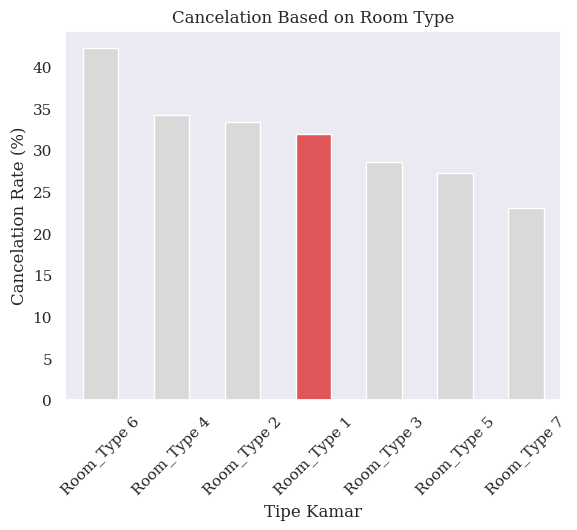

In [ ]:
room_cancel_rate.plot(kind='bar', color = ['#D9D9D9', '#D9D9D9', '#D9D9D9','#E15759','#D9D9D9', '#D9D9D9'])

plt.title('Cancelation Based on Room Type')
plt.xlabel('Tipe Kamar')
plt.ylabel('Cancelation Rate (%)')
plt.xticks(rotation=45)
plt.grid(False)
plt.savefig('room_type_cancelation.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

plt.show()

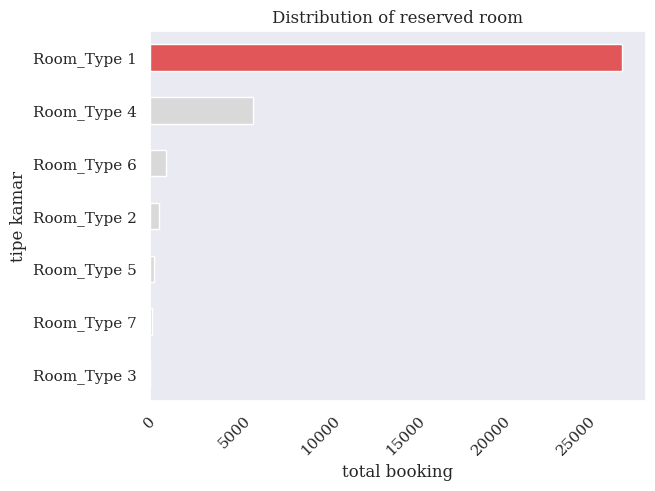

In [ ]:
rt = df_clean['room_type_reserved'].value_counts(ascending=True)
rt.plot(kind='barh', color = ['#E15759', '#D9D9D9', '#D9D9D9', '#D9D9D9', '#D9D9D9', '#D9D9D9'])

plt.title('Distribution of reserved room')
plt.xlabel('total booking')
plt.ylabel('tipe kamar')
plt.xticks(rotation=45)
plt.grid(False)
plt.savefig('room_distribution.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

plt.show()

- Room_Type 6 memiliki persentase pembatalan paling tinggi.
- Room_Type 7 memiliki batang paling rendah, sehingga tipe kamar ini memiliki cancellation rate paling kecil dibandingkan tipe kamar lainnya.

ini memperkuat bahwa terdapat perbedaan pola cancellation berdasarkan tipe kamar.

In [ ]:
room_count = df_clean['room_type_reserved'].value_counts()

room_summary = pd.DataFrame({
    'total_booking': room_count,
    'cancelation_rate': room_cancel_rate
})

room_summary = room_summary.sort_values(by='cancelation_rate', ascending=False)

print(room_summary)

                    total_booking  cancelation_rate
room_type_reserved                                 
Room_Type 6                   962         42.203742
Room_Type 4                  6039         34.260639
Room_Type 2                   548         33.394161
Room_Type 1                 27666         31.901974
Room_Type 3                     7         28.571429
Room_Type 5                   261         27.203065
Room_Type 7                   156         23.076923


ini menunjukkan total booking dan cancellation rate untuk setiap tipe kamar.
- Room_Type 6 memiliki cancellation rate tertinggi sebesar 42.20% dengan total 962 booking, sehingga hasil ini masih cukup relevan untuk dianalisis.
- Room_Type 1 memiliki jumlah booking terbanyak, yaitu 27.675 booking, dengan cancellation rate sebesar 31.89%.
- Room_Type 3 memiliki cancellation rate sebesar 28.57%, tetapi hanya memiliki 7 booking, sehingga hasilnya kurang kuat untuk dijadikan kesimpulan utama.

### **Kesimpulan nomor 7**


Berdasarkan hasil analisis,
- pemesanan dengan tipe kamar tertentu memang memiliki pattern cancellation yang berbeda. Hal ini terlihat dari perbedaan cancellation rate antar room type. Room_Type 6 memiliki cancellation rate tertinggi sebesar 42.20%, sehingga tipe kamar ini paling berisiko mengalami pembatalan. Sebaliknya, Room_Type 7 memiliki cancellation rate terendah sebesar 23.08%, sehingga tipe kamar ini cenderung paling jarang dibatalkan.

- Namun, jika melihat jumlah booking, Room_Type 7 hanya memiliki 156 data dan Room_Type 3 hanya memiliki 7 data, sehingga hasil pada tipe kamar dengan jumlah booking kecil perlu diinterpretasikan dengan hati-hati. Kesimpulan yang lebih kuat dapat diambil dari tipe kamar dengan jumlah data cukup besar, seperti Room_Type 1, Room_Type 4, dan Room_Type 6. Dari ketiganya, Room_Type 6 tetap memiliki cancellation rate paling tinggi, yaitu 42.20%.

**Jadi, dapat disimpulkan bahwa tipe kamar berpengaruh terhadap pola cancellation. Booking pada Room_Type 6 cenderung lebih sering cancel, sedangkan Room_Type 7 cenderung lebih jarang cancel, tetapi hasil untuk room type dengan jumlah data kecil tidak bisa dijadikan acuan utama.**

## **8.Hubungan market_segment_type ke cancelation. Apakah booking dari channel tertentu lebih sering cancel?**

In [ ]:
#business question no 8
#hipotesis = booking dari market segment tertentu memiliki tingkat cancelation yang lebih tinggi
#misalnya booking dari Online memiliki kemungkinan cancel lebih besar dibanding Corporate atau Offline

ms = df_clean['market_segment_type'].value_counts(ascending = True)
print(ms)

market_segment_type
Aviation           125
Complementary      373
Corporate         2016
Offline          10335
Online           22790
Name: count, dtype: int64


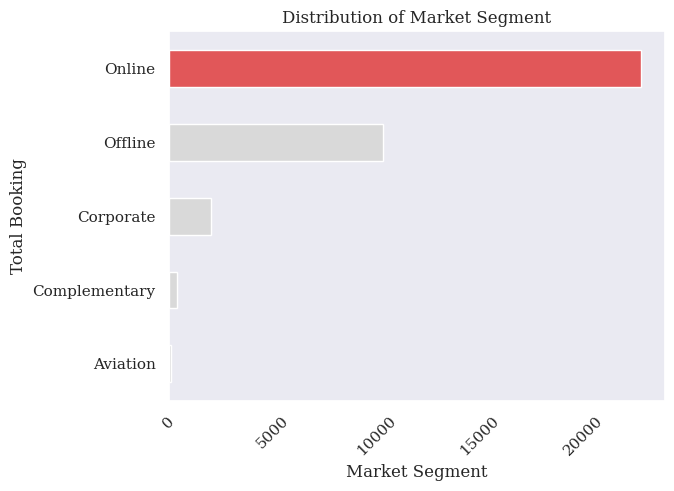

In [ ]:
ms.plot(kind='barh', color = ['#D9D9D9', '#D9D9D9', '#D9D9D9', '#D9D9D9', '#E15759'])

plt.title('Distribution of Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Total Booking')
plt.xticks(rotation=45)
plt.grid(False)
plt.savefig('market_segment_distribution.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

plt.show()

buat nunjukin jumlah booking di tiap market segment --> mayoritas tamu melakukan booking melalui segment Online.

In [ ]:
market_ratio = df_clean.groupby('market_segment_type')['booking_status'].value_counts(normalize=True).unstack() * 100

print(market_ratio)

booking_status        Canceled  Not_Canceled
market_segment_type                         
Aviation             29.600000     70.400000
Complementary              NaN    100.000000
Corporate            10.912698     89.087302
Offline              28.795356     71.204644
Online               36.682756     63.317244


buat nunjukin persentase booking yang Canceled dan Not_Canceled di tiap market segment.
- segment Online memiliki cancellation rate tertinggi sebesar 36.68%,
- Corporate memiliki cancellation rate terendah sebesar 10.91%.
- Segment Complimentary memiliki 100% Not_Canceled dan tidak memiliki nilai Canceled, sehingga muncul nilai NaN pada kolom Canceled.

**Hal ini berarti tidak ada booking dari segment Complimentary yang dibatalkan pada dataset ini.**

In [ ]:
market_cancel_rate = market_ratio['Canceled'].sort_values(ascending=False)

print(market_cancel_rate)

market_segment_type
Online           36.682756
Aviation         29.600000
Offline          28.795356
Corporate        10.912698
Complementary          NaN
Name: Canceled, dtype: float64


urutan market segment berdasarkan cancellation rate dari yang tertinggi sampai terendah.
- Segment Online berada di posisi tertinggi dengan cancellation rate sebesar 36.68%,
- Aviation sebesar 29.60% dan Offline sebesar 28.80%.
- Corporate memiliki cancellation rate paling rendah, yaitu 10.91%.

**Dari hasil ini, booking melalui segment Online dapat dikatakan paling berisiko mengalami pembatalan.**

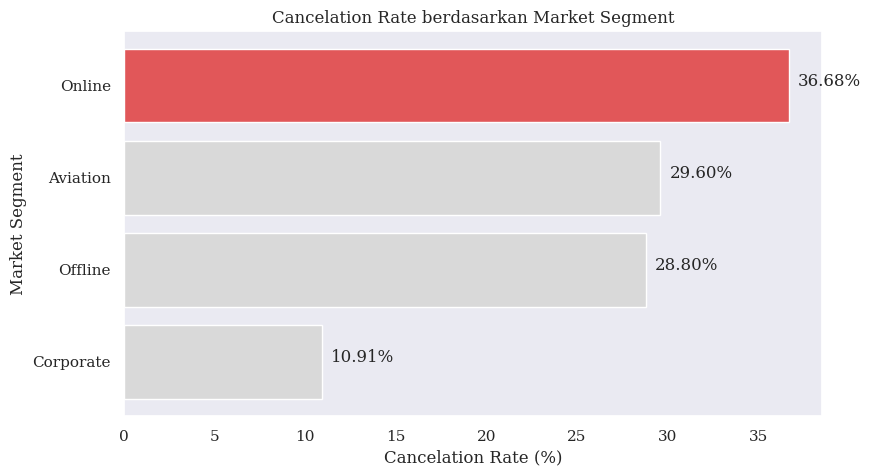

In [ ]:
market_count = df_clean['market_segment_type'].value_counts()

market_ratio = df_clean.groupby('market_segment_type')['booking_status'].value_counts(normalize=True).unstack() * 100

market_summary = pd.DataFrame({
    'total_booking': market_count,
    'cancelation_rate': market_ratio['Canceled']
})

market_summary = market_summary.dropna()
market_summary_plot = market_summary.sort_values('cancelation_rate')

colors = []
for segment in market_summary_plot.index:
    if segment == market_summary['cancelation_rate'].idxmax():
        colors.append('salmon')
    else:
        colors.append('skyblue')

plt.figure(figsize=(9,5))
plt.barh(market_summary_plot.index, market_summary_plot['cancelation_rate'], color=['#D9D9D9', '#D9D9D9', '#D9D9D9', '#E15759'])

plt.title('Cancelation Rate berdasarkan Market Segment')
plt.xlabel('Cancelation Rate (%)')
plt.ylabel('Market Segment')

for i, value in enumerate(market_summary_plot['cancelation_rate']):
    plt.text(value + 0.5, i, f'{value:.2f}%')

plt.grid(False)
plt.savefig('cancellation_market_segment_bar.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()

perbandingan cancellation rate antar market segment
- Segment Online memiliki cancellation rate paling tinggi, yaitu 36.68%.
- Segment Aviation dan Offline memiliki cancellation rate yang cukup mirip, yaitu sekitar 29%.
- Corporate memiliki cancellation rate paling rendah sebesar 10.91%.

ini menunjukkan bahwa channel atau market segment booking memiliki pola cancellation yang berbeda.

### **kesimpulan nomor 8**
Berdasarkan hasil analisis,
- market segment memiliki hubungan dengan cancellation.
- Booking dari segment Online memiliki cancellation rate tertinggi sebesar 36.68%, sehingga segment ini paling sering mengalami pembatalan dibandingkan segment lainnya. Sebaliknya, segment Corporate memiliki cancellation rate terendah sebesar 10.91%, sehingga booking dari Corporate cenderung lebih jarang cancel.

**booking dari channel tertentu memang lebih sering cancel. pada dataset ini, Online menjadi market segment dengan risiko cancellation paling tinggi, sedangkan Corporate menjadi segment dengan risiko cancellation paling rendah.**

## **9. hubungan no_of_special_requests ke cancelation. apakah tamu yang punya special request lebih banyak cenderung lebih jarang cancel?**

In [ ]:
#business question no 9
#hipotesis = semakin banyak special request, kemungkinan tamu untuk cancel semakin kecil

print(df_clean['no_of_special_requests'].value_counts().sort_index())

no_of_special_requests
0    19436
1    11129
2     4324
3      667
4       75
5        8
Name: count, dtype: int64


- paling banyak tamu tidak punya special request, yaitu 19.441 booking.
- ada 11.136 booking dengan 1 special request
- 4.325 booking dengan 2 special request.

**untuk jumlah request 3, 4, dan 5 datanya jauh lebih sedikit. jadi, hasil pada kategori ini perlu dilihat dengan hati-hati karena jumlah datanya kecil**

In [ ]:
#melihat persentase cancel berdasarkan jumlah special request

request_ratio = df_clean.groupby('no_of_special_requests')['booking_status'].value_counts(normalize=True).unstack() * 100

print(request_ratio)

booking_status           Canceled  Not_Canceled
no_of_special_requests                         
0                       43.162173     56.837827
1                       23.092821     76.907179
2                       14.662350     85.337650
3                             NaN    100.000000
4                             NaN    100.000000
5                             NaN    100.000000


- booking tanpa special request memiliki cancellation rate paling tinggi, yaitu 43.15%.
- booking dengan 1 special request memiliki cancellation rate 23.08%
-  booking dengan 2 special request memiliki cancellation rate 14.66%.
- untuk special request 3, 4, dan 5, hasil canceled muncul NaN karena tidak ada booking yang cancel pada kategori tersebut. artinya, semua booking dengan 3 sampai 5 special request berstatus not_canceled.

In [ ]:
#menampilkan hanya cancellation rate

request_cancel_rate = request_ratio['Canceled'].sort_index()

print(request_cancel_rate)

no_of_special_requests
0    43.162173
1    23.092821
2    14.662350
3          NaN
4          NaN
5          NaN
Name: Canceled, dtype: float64


- semakin banyak special request, cancellation rate semakin turun.
- booking dengan 0 request memiliki cancellation rate 43.15%
- lalu turun menjadi 23.08% pada 1 request
- turun lagi menjadi 14.66% pada 2 request.

untuk 3, 4, dan 5 request nilainya NaN karena tidak ada data canceled pada kategori tersebut.

In [ ]:
#membuat summary total booking dan cancellation rate

request_count = df_clean['no_of_special_requests'].value_counts().sort_index()

request_summary = pd.DataFrame({
    'total_booking': request_count,
    'cancelation_rate': request_cancel_rate
})

print(request_summary)

                        total_booking  cancelation_rate
no_of_special_requests                                 
0                               19436         43.162173
1                               11129         23.092821
2                                4324         14.662350
3                                 667               NaN
4                                  75               NaN
5                                   8               NaN


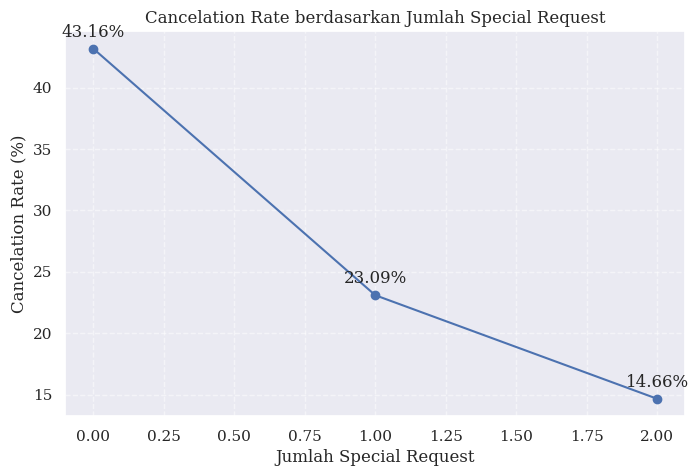

In [ ]:
#visualisasi cancellation rate berdasarkan jumlah special request

plt.figure(figsize=(8,5))

plt.plot(
    request_cancel_rate.index,
    request_cancel_rate.values,
    marker='o'
)

plt.title('Cancelation Rate berdasarkan Jumlah Special Request')
plt.xlabel('Jumlah Special Request')
plt.ylabel('Cancelation Rate (%)')

for x, y in zip(request_cancel_rate.index, request_cancel_rate.values):
    plt.text(x, y + 1, f'{y:.2f}%', ha='center')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

grafik ini menunjukkan perubahan cancellation rate berdasarkan jumlah special request.

- cancellation rate turun ketika jumlah special request bertambah.
- booking tanpa special request memiliki tingkat cancel paling tinggi,
- booking dengan 1 dan 2 request lebih jarang cancel.

**jadi, grafik ini menunjukkan bahwa tamu yang punya special request lebih jarang membatalkan booking.**

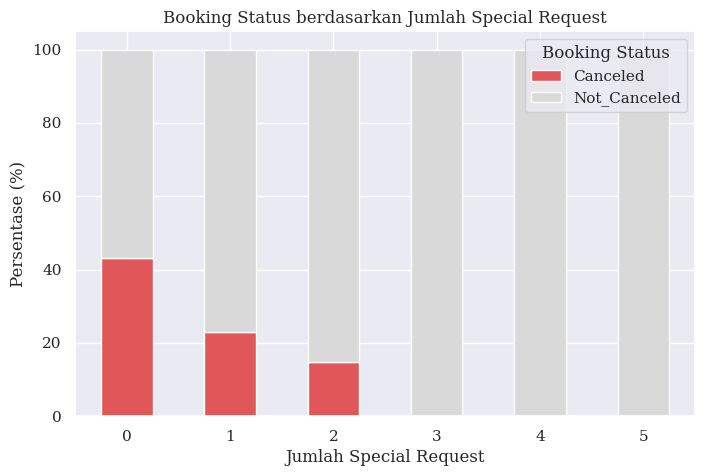

In [ ]:
#visualisasi perbandingan canceled dan not_canceled berdasarkan jumlah special request

request_ratio_plot = request_ratio.fillna(0)

request_ratio_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color = ['#E15759', '#D9D9D9']
)

plt.title('Booking Status berdasarkan Jumlah Special Request')
plt.xlabel('Jumlah Special Request')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Booking Status')
plt.savefig('special_request_bar.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

plt.show()

- pada 0 special request, bagian canceled masih cukup besar.
- saat jumlah special request bertambah, bagian canceled semakin kecil dan bagian not_canceled semakin besar.
- pada 3, 4, dan 5 special request, seluruh booking berstatus not_canceled. artinya, tidak ada pembatalan pada kategori tersebut.

## **Kesimpulan nomor 9**
berdasarkan hasil analisis, **jumlah special request memiliki hubungan dengan cancellation.** semakin banyak special request yang dimiliki tamu, kemungkinan cancel cenderung semakin kecil.

booking tanpa special request memiliki cancellation rate paling tinggi, yaitu 43.15%. sedangkan booking dengan 1 dan 2 special request memiliki cancellation rate yang lebih rendah. jadi, tamu yang memiliki special request terlihat lebih serius dalam melakukan booking dan cenderung lebih jarang cancel.

## **10. Hubungan harga kamar ke cancelation. Apakah booking dengan avg_price_per_room tinggi lebih sering cancel?**

In [ ]:
#business question no 10
#hipotesis = harga kamar yang lebih tinggi memiliki kemungkinan cancel lebih besar

print(df_clean['avg_price_per_room'].describe())

count    35639.000000
mean       104.249591
std         34.124373
min          0.000000
25%         80.750000
50%         99.900000
75%        121.000000
max        375.500000
Name: avg_price_per_room, dtype: float64


- total data yang dipakai ada 35.652 booking.

- rata-rata harga kamar adalah 104.21. harga paling rendah adalah 0, sedangkan harga paling tinggi adalah 375.50.

- nilai tengah atau median harga kamar adalah 99.90. artinya, sebagian booking punya harga di bawah 99.90 dan sebagian lainnya di atas 99.90.



In [ ]:
#buat kategori harga kamar berdasarkan quartile

price_labels = ['Low Price', 'Medium Price', 'High Price', 'Very High Price']

df_clean['price_category'] = pd.qcut(
    df_clean['avg_price_per_room'],
    q=4,
    labels=price_labels
)

print(df_clean['price_category'].value_counts())

price_category
Low Price          9089
High Price         8934
Very High Price    8882
Medium Price       8734
Name: count, dtype: int64


harga kamar dibagi menjadi 4 kategori, yaitu low price, medium price, high price, dan very high price.

pembagian ini dibuat berdasarkan quartile, jadi jumlah data di setiap kategori hampir seimbang.
- low price memiliki 9.102 booking,
- high price 8.934 booking,
- very high price 8.882 booking,
- medium price 8.734 booking.

jadi, kategori harga ini dibuat supaya lebih mudah membandingkan tingkat cancel antara booking dengan harga rendah, sedang, tinggi, dan sangat tinggi.

In [ ]:
#melihat persentase cancel berdasarkan kategori harga

price_ratio = df_clean.groupby('price_category')['booking_status'].value_counts(normalize=True).unstack() * 100

print(price_ratio)

booking_status    Canceled  Not_Canceled
price_category                          
Low Price        21.322478     78.677522
Medium Price     28.681017     71.318983
High Price       42.556526     57.443474
Very High Price  37.694213     62.305787


/tmp/ipykernel_11736/1138149079.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_ratio = df_clean.groupby('price_category')['booking_status'].value_counts(normalize=True).unstack() * 100




dari hasilnya,
- low price memiliki tingkat cancel paling rendah, yaitu 21.29%.
- medium price naik menjadi 28.68%.
- high price memiliki tingkat cancel paling tinggi, yaitu 42.56%.
- very high price juga cukup tinggi, yaitu 37.69%.

artinya, booking dengan harga kamar yang lebih tinggi cenderung lebih sering dibatalkan dibandingkan booking dengan harga rendah. namun, kategori very high price sedikit lebih rendah dibanding high price, jadi kenaikannya tidak selalu terus naik.

In [ ]:
#menampilkan hanya cancelation rate

price_cancel_rate = price_ratio['Canceled'].sort_values(ascending=False)

print(price_cancel_rate)

price_category
High Price         42.556526
Very High Price    37.694213
Medium Price       28.681017
Low Price          21.322478
Name: Canceled, dtype: float64


In [ ]:
#membuat summary total booking dan cancelation rate

price_count = df_clean['price_category'].value_counts()

price_summary = pd.DataFrame({
    'total_booking': price_count,
    'cancelation_rate': price_ratio['Canceled']
})

price_summary = price_summary.sort_values('cancelation_rate', ascending=False)

print(price_summary)

                 total_booking  cancelation_rate
price_category                                  
High Price                8934         42.556526
Very High Price           8882         37.694213
Medium Price              8734         28.681017
Low Price                 9089         21.322478


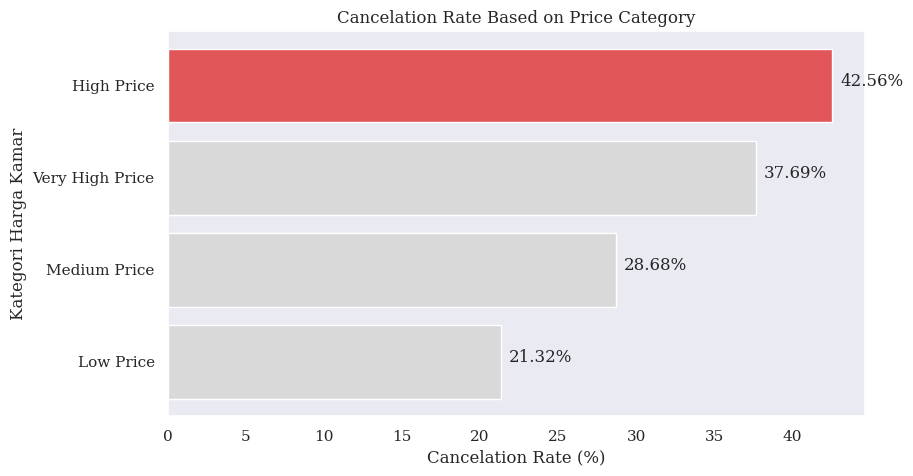

In [ ]:
#visualisasi cancelation rate berdasarkan kategori harga

price_summary_plot = price_summary.sort_values('cancelation_rate')

colors = []
for price in price_summary_plot.index:
    if price == price_summary['cancelation_rate'].idxmax():
        colors.append('#E15759')
    else:
        colors.append('#D9D9D9')

plt.figure(figsize=(9,5))
plt.barh(price_summary_plot.index, price_summary_plot['cancelation_rate'], color=colors)

plt.title('Cancelation Rate Based on Price Category')
plt.xlabel('Cancelation Rate (%)')
plt.ylabel('Kategori Harga Kamar')

for i, value in enumerate(price_summary_plot['cancelation_rate']):
    plt.text(value + 0.5, i, f'{value:.2f}%')

plt.grid(False)
plt.savefig('high_price_bar.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()


- Kategori High Price memiliki cancellation rate paling tinggi (warna merah)
- Low Price memiliki cancellation rate paling rendah.

 **Dari grafik ini terlihat bahwa semakin tinggi kategori harga, cancellation rate meningkat, meskipun kategori Very High Price sedikit lebih rendah dibandingkan High Price.**

### **Kesimpulan nomor 10**

**harga kamar ternyata berpengaruh terhadap kemungkinan cancel. booking dengan harga kamar yang lebih mahal cenderung lebih sering dibatalkan dibandingkan booking dengan harga yang lebih murah.**

dari hasil analisis, kategori high price punya cancellation rate paling tinggi, yaitu 42.56%. sedangkan kategori low price punya cancellation rate paling rendah, yaitu 21.29%.

jadi, bisa dibilang semakin mahal harga kamar, kemungkinan tamu untuk cancel juga cenderung lebih besar. tapi polanya tidak selalu naik terus, karena kategori very high price sedikit lebih rendah dibanding high price.


In [ ]:
df_clean['repeated_guest'].value_counts()

,count
repeated_guest,
0,34719
1,920


In [ ]:
repeated_guest = df_clean['repeated_guest'].value_counts(normalize=True)*100

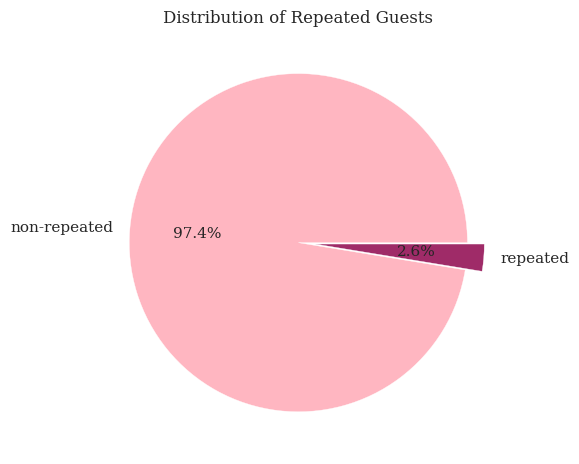

In [ ]:
plt.pie(
    repeated_guest,
    labels = ['non-repeated', 'repeated'],
    autopct = '%1.1f%%',
    colors = ['#FFB6C1','#9F2B68'],
    explode = (0,0.1),
    wedgeprops={'edgecolor': 'white', 'linewidth':0.25},
    textprops={'fontsize': 11}

)
plt.title('Distribution of Repeated Guests')
plt.tight_layout()
plt.show()

In [ ]:
cancel_rate_guest = (df_clean.groupby('repeated_guest')['booking_status'].value_counts(normalize=True).unstack()*100)
print(cancel_rate_guest)

booking_status   Canceled  Not_Canceled
repeated_guest                         
0               33.344854     66.655146
1                1.739130     98.260870


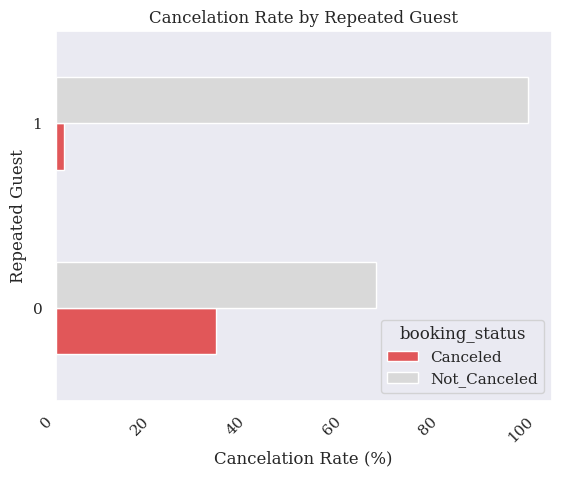

In [ ]:
cancel_rate_guest.plot(kind ='barh', color = ['#E15759', '#D9D9D9'])
plt.xlabel('Cancelation Rate (%)')
plt.ylabel('Repeated Guest')
plt.title('Cancelation Rate by Repeated Guest')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.savefig('cancelation_repeated_guest.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)
plt.show()

In [ ]:
df_clean.to_csv('hotel_bookings_cleaned.csv', index=False)


# **Conclusion**

Berdasarkan hasil Exploratory Data Analysis (EDA) yang telah dilakukan pada dataset Hotel Reservations, dapat disimpulkan bahwa data reservasi hotel memiliki berbagai faktor yang memengaruhi status pemesanan pelanggan, terutama terkait pembatalan reservasi (booking cancellation).

Dari proses analisis, ditemukan bahwa beberapa variabel seperti lead time, harga rata-rata kamar (avg_price_per_room), jumlah permintaan khusus (no_of_special_requests), serta market segment memiliki hubungan terhadap kemungkinan pelanggan membatalkan reservasi. Pelanggan dengan lead time yang lebih panjang cenderung memiliki kemungkinan pembatalan yang lebih tinggi dibanding pelanggan yang melakukan pemesanan mendekati tanggal check-in.

Selain itu, hasil visualisasi menunjukkan adanya pola tertentu pada tipe kamar, jenis meal plan, dan segmentasi pelanggan yang dapat digunakan untuk memahami perilaku customer dalam melakukan reservasi hotel. Proses data cleaning juga membantu meningkatkan kualitas data dengan menangani missing value, data duplikat, serta memastikan tipe data sesuai untuk proses analisis.

Melalui EDA ini, diperoleh pemahaman yang lebih baik mengenai karakteristik data dan hubungan antar variabel dalam dataset hotel reservations. Insight yang diperoleh dapat membantu pihak hotel dalam meningkatkan strategi bisnis, pelayanan pelanggan, dan pengambilan keputusan berbasis data.

## **Suggestions**

Beberapa saran yang dapat dilakukan berdasarkan hasil analisis ini antara lain:

1. Hotel dapat memberikan perhatian lebih pada pelanggan dengan lead time yang tinggi karena kelompok tersebut memiliki potensi pembatalan reservasi yang lebih besar.

2. Pihak hotel dapat meningkatkan strategi promosi dan customer engagement untuk mengurangi tingkat pembatalan reservasi, misalnya melalui reminder booking atau penawaran khusus.

3. Analisis lebih lanjut dapat dilakukan menggunakan machine learning classification untuk memprediksi kemungkinan pembatalan reservasi berdasarkan variabel-variabel yang tersedia.

4. Penambahan data lain seperti ulasan pelanggan, musim liburan, atau metode pembayaran dapat membantu menghasilkan analisis yang lebih mendalam dan akurat.

5. Visualisasi dan analisis data secara berkala dapat membantu hotel memahami perubahan perilaku pelanggan dari waktu ke waktu sehingga strategi bisnis dapat disesuaikan dengan lebih efektif.